# putEMG — Feature-Based Model Comparison

Trains and evaluates three model families on hand-crafted EMG features (192-dim vectors):

| # | Model | Notes |
|---|-------|-------|
| 1 | **SVM** | RBF kernel + StandardScaler, full-batch training |
| 2 | **XGBoost** | Gradient boosting, early stopping on val set |
| 3 | **MLP** | 192→256→128→64→7, PyTorch, early stopping + ReduceLROnPlateau |

**Input**: `.mat` files produced by `feature_extraction.batch_extract_features`  
**Data split**: 80% train+val · 20% test (train further split 90/10 for early stopping)

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

# ── Shared utilities (public/) ────────────────────────────────────────────────
# VS Code Jupyter sets cwd = workspace root; classic Jupyter sets cwd = notebook dir.
# Check both so the path resolves correctly in either environment.
_CWD    = os.getcwd()
_ROOT   = _CWD if os.path.isdir(os.path.join(_CWD, 'public')) else \
          os.path.abspath(os.path.join(_CWD, '..', '..', '..', '..'))
_PUBLIC = os.path.join(_ROOT, 'public')
if _PUBLIC not in sys.path:
    sys.path.insert(0, _PUBLIC)

from emg_loader import load_feature_subjects

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
FEATURES_DIR  = os.path.join(_PROJECT_ROOT, 'Data', 'X', 'feature_files')   # folder with features_subject_*_flat_window.npz files

# ── Labels ────────────────────────────────────────────────────────────────────
GESTURE_NAMES = ['G1', 'G2', 'G3', 'G6', 'G7', 'G8', 'G9']
N_CLASSES     = 7
INPUT_DIM     = 192   # 8 features × 24 channels

# ── Data split ────────────────────────────────────────────────────────────────
TEST_SIZE    = 0.2
DEV_SIZE     = 0.1
RANDOM_STATE = 42

# ── MLP hyperparameters ───────────────────────────────────────────────────────
BATCH_SIZE = 64
MAX_EPOCHS = 15
PATIENCE   = 3
MIN_DELTA  = 0.002
LR         = 1e-3
DROPOUT    = 0.3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

---
## Data Loading

In [ ]:
subjects = load_feature_subjects(FEATURES_DIR, mode='flat_window')
X = np.concatenate([X_s for _, X_s, _ in subjects], axis=0)
y = np.concatenate([y_s for _, _, y_s in subjects], axis=0)
print(f'\nCombined : X={X.shape}, y={y.shape}')
print(f'Classes  : { {GESTURE_NAMES[i]: int((y == i).sum()) for i in range(N_CLASSES)} }')

In [9]:
# 80/20 train+val / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
# 90/10 train / val (from the training portion only)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=DEV_SIZE, stratify=y_train, random_state=RANDOM_STATE
)

print(f'Train : {len(X_train):>7,} windows')
print(f'Val   : {len(X_val):>7,} windows')
print(f'Test  : {len(X_test):>7,} windows')

# PyTorch DataLoaders (used by MLP only)
def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

Train : 202,118 windows
Val   :  22,458 windows
Test  :  56,145 windows


---
## Evaluation Helpers

In [10]:
def eval_sklearn(model, X, y, name):
    """Accuracy + confusion matrix for any sklearn-compatible model."""
    y_pred = model.predict(X)
    acc    = accuracy_score(y, y_pred)
    print(f'  Test accuracy: {acc * 100:.2f}%')
    cm  = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=GESTURE_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — Test Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return acc


def eval_mlp(model, loader, device, name):
    """Accuracy + confusion matrix for the PyTorch MLP."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(device)).argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels.append(y_b)
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = (all_preds == all_labels).mean()
    print(f'  Test accuracy: {acc * 100:.2f}%')
    cm  = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=GESTURE_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — Test Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return float(acc)

---
## 1 — SVM (RBF kernel)

StandardScaler + RBF SVM trained on the full training set in one shot (no batching).  
> **Note**: SVM with RBF scales as O(n²–n³) — may be slow on large datasets. Swap `SVC` for `LinearSVC` if needed.

In [13]:
print('Training SVM...')
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LinearSVC(C=1.0,tol=1e-5, random_state=RANDOM_STATE)),
])
svm.fit(X_train, y_train)
print('Done.')

print('\n--- SVM — Test Set Evaluation ---')
svm_acc = eval_sklearn(svm, X_test, y_test, 'SVM (RBF)')

Training SVM...


---
## 2 — XGBoost

Gradient-boosted trees with early stopping monitored on the validation set.

Training XGBoost...
[0]	validation_0-mlogloss:1.88535
[50]	validation_0-mlogloss:1.04341
[100]	validation_0-mlogloss:0.85189
[150]	validation_0-mlogloss:0.75142
[200]	validation_0-mlogloss:0.68509
[250]	validation_0-mlogloss:0.63918
[300]	validation_0-mlogloss:0.60398
[350]	validation_0-mlogloss:0.57679
[400]	validation_0-mlogloss:0.55407
[450]	validation_0-mlogloss:0.53595
[499]	validation_0-mlogloss:0.51952
Best iteration: 499

--- XGBoost — Test Set Evaluation ---
  Test accuracy: 83.68%


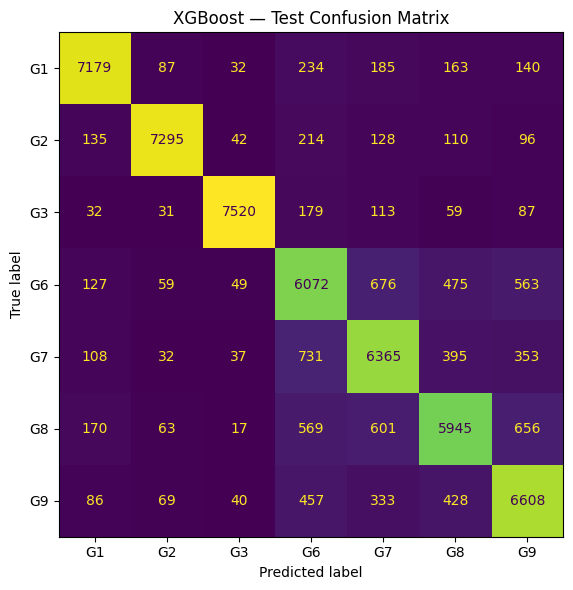

In [7]:
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 20,
    random_state          = RANDOM_STATE,
    n_jobs                = -1,
)
xgb.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 50,
)
print(f'Best iteration: {xgb.best_iteration}')

print('\n--- XGBoost — Test Set Evaluation ---')
xgb_acc = eval_sklearn(xgb, X_test, y_test, 'XGBoost')

---
## 3 — MLP (PyTorch)

Feed-forward network: **192 → 256 → 128 → 64 → 7**  
Each hidden layer: `Linear → BatchNorm1d → ReLU → Dropout`  
Training: Adam + ReduceLROnPlateau + early stopping — same setup as the deep learning notebook.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=192, hidden_dims=(256, 128, 64),
                 n_classes=7, dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_mlp(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            preds    = model(X_b.to(device)).argmax(dim=1).cpu()
            correct += (preds == y_b).sum().item()
            total   += y_b.size(0)
    return correct / total

In [10]:
mlp       = MLP(dropout=DROPOUT).to(device)
optimizer = optim.Adam(mlp.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.CrossEntropyLoss()

best_val_acc = float('-inf')
best_state   = None
bad_epochs   = 0

for epoch in range(MAX_EPOCHS):
    tr_loss = train_epoch(mlp, train_loader, criterion, optimizer, device)
    val_acc = evaluate_mlp(mlp, val_loader, device)
    curr_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}

    scheduler.step(val_acc)

    if val_acc >= (best_val_acc - MIN_DELTA):
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(f'Epoch {epoch+1:3d}: loss={tr_loss:.4f}  val={val_acc*100:.2f}%  '
          f'best={best_val_acc*100:.2f}%  lr={curr_lr:.2e}')

    if bad_epochs >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}.')
        break

# Restore best weights before evaluation
mlp.load_state_dict(best_state)

In [ ]:
print('--- MLP — Test Set Evaluation ---')
mlp_acc = eval_mlp(mlp, test_loader, device, 'MLP')

---
## Results Summary

In [ ]:
results = {
    'SVM (RBF)': svm_acc,
    'XGBoost':   xgb_acc,
    'MLP':       mlp_acc,
}

print(f"{'Model':<14} {'Test Acc':>10}")
print('-' * 26)
for name, acc in results.items():
    print(f"{name:<14} {acc * 100:>9.2f}%")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(results.keys())
accs  = [v * 100 for v in results.values()]
bars  = ax.bar(names, accs, color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Feature-Based Model Comparison')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()